In [1]:
# Plot regional mortality difference as a boxplot per 100k

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from utils.utils import get_scenario_config

In [3]:
def load_regional_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_first_decade_for_plotting(da):
    # Select the first 10 years
    da_first10 = da.isel(year=slice(0, 10))

    # Get the first and last time values
    start_time = da_first10.year[0].item()
    end_time = da_first10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_first10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [5]:
def process_final_decade_for_plotting(da):
    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [6]:
def process_mortality_per_100k(da, last_decade=True):
    """
    If last_decade = True, calculate final decade average
    If last_decade = False, calculate first decade average
    """
    # === Path config ===
    MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/region/"
    POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

    # === Load data ===
    mask_file = "GBD_Region_Masks_0.10.nc"
    mask_path = os.path.join(MASK_DIR, mask_file)
    mask = xr.open_dataarray(mask_path)

    pop_file = "ssp2_region_level_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    population = xr.open_dataarray(pop_path)
    pop = population.reindex_like(mask, method="nearest", tolerance=1e-9)

    if last_decade is True:
        da_mean, start_time, end_time = process_final_decade_for_plotting(da)
    else:
        # First decade
        da_mean, start_time, end_time = process_first_decade_for_plotting(da)

    # Calculate population mean
    years = slice(start_time, end_time)
    av_pop = pop.sel(year=years).mean("year")

    # Calculate mortality per 100,000
    da_per_100k = (da_mean/av_pop)*100000
    return da_per_100k, start_time, end_time

In [7]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional/"

model = "UKESM1"
scenario1 = "SSP245_G6"
scenario2 = "G6-1.5K"

n_samples = 300

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1 = load_regional_mortality_ensemble_members(model, scenario1, config1, n_samples)
da2 = load_regional_mortality_ensemble_members(model, scenario2, config2, n_samples)

# Match years
da1 = da1.sel(year=da2.year)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


In [11]:
def plot_regional_difference_boxplot(da, model, difference_name, start_year, end_year, out_path):

    # Sort regions by mean value - high to low
    region_means = da.mean(dim="samples")
    sorted_regions = region_means.sortby(region_means).region.values

    data = [difference.sel(region=r).values for r in sorted_regions]

    # Calculate IQRs and assign colours
    colours = []
    for vals in data:
        q1, q3 = np.percentile(vals, [25, 75])
        if q1 > 0:
            colours.append('red')  # entirely positive IQR
        elif q3 < 0:
            colours.append('blue')  # entirely negative IQR
        else:
            colours.append('grey')  # crosses zero

    plt.figure(figsize=(8, 10))
    bp = plt.boxplot(
        data, vert=False, patch_artist=True, sym='+',
        boxprops=dict(color='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray')
    )

    # Apply the computed colours to boxes
    for patch, colour in zip(bp['boxes'], colours):
        patch.set_facecolor(colour)

    plt.yticks(np.arange(1, len(sorted_regions) + 1), sorted_regions)
    plt.xlabel("Mortality per 100k (per year)")
    plt.title(f"COPD Mortality due to surface ozone\n {model} {difference_name} {start_year}-{end_year}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Symmetric log scale with real-number tick labels
    plt.xscale('symlog', linthresh=0.01)
    plt.xlim(-1, 1)

    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    plt.gca().xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    return

Years are the same


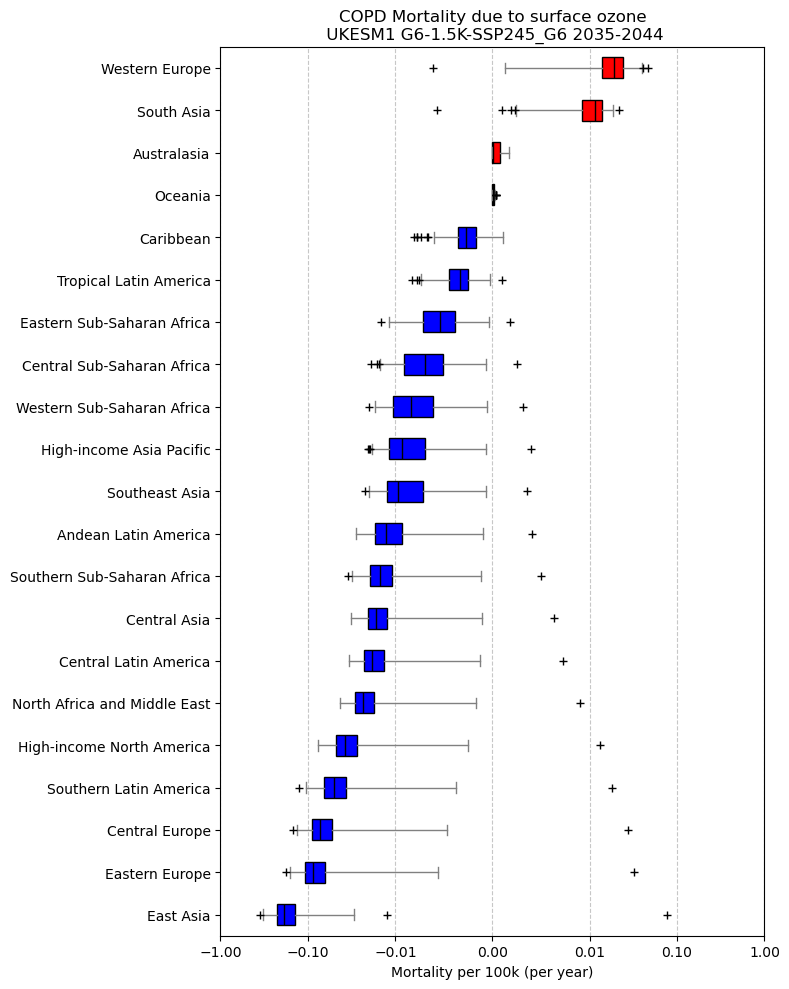

In [12]:
# First 10 years
da1_mean, first_year1, last_year1 = process_mortality_per_100k(da1, last_decade=False)
da2_mean, first_year2, last_year2 = process_mortality_per_100k(da2, last_decade=False)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")
    difference = da2_mean - da1_mean
    difference_name = f"{scenario2}-{scenario1}"

out_file = f"Mortality_per_100k_region_boxplot_{model}_{difference_name}_{first_year1}-{last_year1}.png"
out_path = os.path.join(SAVE_DIR, out_file)

plot_regional_difference_boxplot(difference, model, difference_name, first_year1, last_year1, out_path)

Years are the same


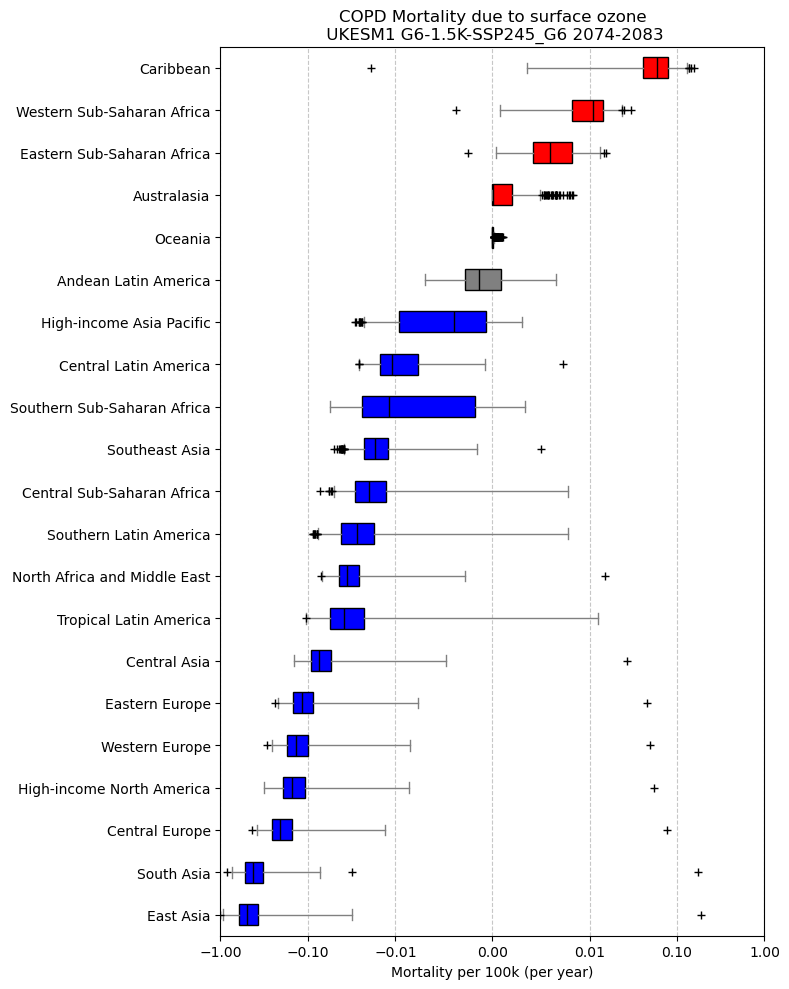

In [13]:
# Last 10 years
da1_mean, first_year1, last_year1 = process_mortality_per_100k(da1, last_decade=True)
da2_mean, first_year2, last_year2 = process_mortality_per_100k(da2, last_decade=True)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")
    difference = da2_mean - da1_mean
    difference_name = f"{scenario2}-{scenario1}"

out_file = f"Mortality_per_100k_region_boxplot_{model}_{difference_name}_{first_year1}-{last_year1}.png"
out_path = os.path.join(SAVE_DIR, out_file)

plot_regional_difference_boxplot(difference, model, difference_name, first_year1, last_year1, out_path)